# Import

In [3]:
from pathlib import Path
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Configure device

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Using device: cpu
Running on CPU


# Load shared vocabulary and sequence data

Loads directly from `data/shared/vocabulary.pkl` and `data/shared/sequence_data.npz` (produced once by `vocab.ipynb`) instead of rebuilding the vocab locally.

In [5]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = DATA_DIR / "shared"

with open(SHARED_DIR / "vocabulary.pkl", "rb") as file:
    vocab = pickle.load(file)

word_to_idx = vocab["word_to_idx"]
MAX_LENGTH = vocab["MAX_LENGTH"]

sequence_data = np.load(SHARED_DIR / "sequence_data.npz")

train_padded = sequence_data["train_padded"]
val_padded = sequence_data["val_padded"]
test_padded = sequence_data["test_padded"]

train_lengths = sequence_data["train_lengths"]
val_lengths = sequence_data["val_lengths"]
test_lengths = sequence_data["test_lengths"]

y_train = sequence_data["y_train"]
y_val = sequence_data["y_val"]
y_test = sequence_data["y_test"]

print(f"Vocabulary size: {len(word_to_idx):,}")
print(f"MAX_LENGTH: {MAX_LENGTH}")
print("Train padded:", train_padded.shape)
print("Val padded:", val_padded.shape)
print("Test padded:", test_padded.shape)

Vocabulary size: 60,725
MAX_LENGTH: 321
Train padded: (19923, 321)
Val padded: (4981, 321)
Test padded: (24801, 321)


# PyTorch Dataset and DataLoaders

In [6]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )


train_dataset = ReviewDataset(train_padded, train_lengths, y_train)
val_dataset = ReviewDataset(val_padded, val_lengths, y_val)
test_dataset = ReviewDataset(test_padded, test_lengths, y_test)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=device.type == "cuda"
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=device.type == "cuda"
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=device.type == "cuda"
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

sequences_batch, lengths_batch, labels_batch = next(iter(train_loader))
print("Sequences shape:", sequences_batch.shape)
print("Lengths shape:", lengths_batch.shape)
print("Labels shape:", labels_batch.shape)

Training batches: 623
Validation batches: 156
Testing batches: 776
Sequences shape: torch.Size([32, 321])
Lengths shape: torch.Size([32])
Labels shape: torch.Size([32])


# Embeddings

Train a local Word2Vec on the training corpus, load pretrained GloVe, and build an embedding matrix indexed by the **shared** `word_to_idx` (so rows line up with the vocab used in the other models) for each. We only need the raw training text (not the vocab) here, so we reload `train_processed.csv` and redo the identical train/val split just to get the token lists for the Word2Vec corpus.

In [7]:
from sklearn.model_selection import train_test_split

train_df = pd.read_csv(DATA_DIR / "train_processed.csv")
train_data, _ = train_test_split(
    train_df, test_size=0.2, random_state=SEED, stratify=train_df["label"]
)
train_tokens = train_data["processed_text"].str.split()

print("Training samples for Word2Vec corpus:", len(train_tokens))

Training samples for Word2Vec corpus: 19923


## Word2Vec

In [9]:
from gensim.models import Word2Vec
import time

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

start_time = time.time()

word2vec_model = Word2Vec(
    sentences=train_tokens.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=SEED
)

elapsed_time = time.time() - start_time

print("Word2Vec training completed.")
print("Vector size:", word2vec_model.vector_size)
print("Vocabulary size:", len(word2vec_model.wv))
print(f"Training time: {elapsed_time / 60:.2f} minutes")

WORD2VEC_PATH = MODELS_DIR / "word2vec_imdb.model"
word2vec_model.save(str(WORD2VEC_PATH))
print("Word2Vec model saved to:", WORD2VEC_PATH)

Word2Vec training completed.
Vector size: 100
Vocabulary size: 37953
Training time: 0.69 minutes
Word2Vec model saved to: models\word2vec_imdb.model


In [10]:
word2vec_vectors = word2vec_model.wv
WORD2VEC_DIM = word2vec_vectors.vector_size

rng = np.random.default_rng(SEED)

word2vec_embedding_matrix = rng.normal(
    loc=0.0, scale=0.05, size=(len(word_to_idx), WORD2VEC_DIM)
).astype(np.float32)

word2vec_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0
for word, idx in word_to_idx.items():
    if word in word2vec_vectors:
        word2vec_embedding_matrix[idx] = word2vec_vectors[word]
        matched_words += 1

word2vec_coverage = matched_words / len(word_to_idx) * 100

print("Word2Vec matrix shape:", word2vec_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {word2vec_coverage:.2f}%")

np.save(MODELS_DIR / "word2vec_embedding_matrix.npy", word2vec_embedding_matrix)
print("Word2Vec embedding matrix saved.")

Word2Vec matrix shape: (60725, 100)
Matched words: 37953
Vocabulary coverage: 62.50%
Word2Vec embedding matrix saved.


## GloVe

In [11]:
import gensim.downloader as api

start_time = time.time()

print("Loading pretrained GloVe...")
glove_model = api.load("glove-wiki-gigaword-100")

elapsed_time = time.time() - start_time

print("GloVe loaded successfully.")
print("Vector size:", glove_model.vector_size)
print(f"Loading time: {elapsed_time / 60:.2f} minutes")

Loading pretrained GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded successfully.
Vector size: 100
Loading time: 2.13 minutes


In [12]:
GLOVE_DIM = glove_model.vector_size

rng = np.random.default_rng(SEED)

glove_embedding_matrix = rng.normal(
    loc=0.0, scale=0.05, size=(len(word_to_idx), GLOVE_DIM)
).astype(np.float32)

glove_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0
for word, idx in word_to_idx.items():
    if word in glove_model:
        glove_embedding_matrix[idx] = glove_model[word]
        matched_words += 1

glove_coverage = matched_words / len(word_to_idx) * 100

print("GloVe matrix shape:", glove_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {glove_coverage:.2f}%")

np.save(MODELS_DIR / "glove_embedding_matrix.npy", glove_embedding_matrix)
print("GloVe embedding matrix saved.")

GloVe matrix shape: (60725, 100)
Matched words: 49464
Vocabulary coverage: 81.46%
GloVe embedding matrix saved.


# RNN Model

In [18]:
from torch.nn.utils.rnn import pack_padded_sequence


class RNNClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )

        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings,
            padding_idx=word_to_idx["<PAD>"]
        )

        embedding_dim = embedding_matrix.shape[1]

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.output(final_hidden).squeeze(1)

        return logits

# Training functions

In [19]:
import time
import copy

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(sequences, lengths)
        loss = criterion(logits, labels)

        loss.backward()

        # Helps reduce exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * labels.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy



def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    model_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_model_state,
                model_path
            )

            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(
        f"\nTraining completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

    return history

# Evaluation functions

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


def evaluate_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)

            logits = model(sequences, lengths)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            all_labels.extend(labels.numpy().astype(int))
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    metrics = {
        "accuracy": accuracy_score(all_labels, all_predictions),
        "precision": precision_score(all_labels, all_predictions, zero_division=0),
        "recall": recall_score(all_labels, all_predictions, zero_division=0),
        "f1": f1_score(all_labels, all_predictions, zero_division=0)
    }

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )


def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

# Experiments

In [21]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 5

## Frozen GloVe RNN

In [22]:
glove_frozen_model = RNNClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(lambda parameter: parameter.requires_grad, glove_frozen_model.parameters()),
    lr=LEARNING_RATE
)

print("Training Frozen GloVe RNN...")
print("Device:", device)

glove_frozen_history = train_model(
    model=glove_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_glove_frozen.pt"
)

Training Frozen GloVe RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.5863 | Train Accuracy: 0.7003 | Val Loss: 0.5901 | Val Accuracy: 0.6888
Best model saved.
Epoch 02/5 | Train Loss: 0.5527 | Train Accuracy: 0.7322 | Val Loss: 0.5172 | Val Accuracy: 0.7587
Best model saved.
Epoch 03/5 | Train Loss: 0.5516 | Train Accuracy: 0.7298 | Val Loss: 0.5485 | Val Accuracy: 0.7432
Epoch 04/5 | Train Loss: 0.5396 | Train Accuracy: 0.7439 | Val Loss: 0.6882 | Val Accuracy: 0.6902
Epoch 05/5 | Train Loss: 0.5454 | Train Accuracy: 0.7414 | Val Loss: 0.5613 | Val Accuracy: 0.7368

Training completed in 4.27 minutes.


In [23]:
(
    glove_frozen_metrics,
    glove_frozen_labels,
    glove_frozen_predictions,
    glove_frozen_probabilities
) = evaluate_model(glove_frozen_model, test_loader, device)

print(glove_frozen_metrics)
print(classification_report(
    glove_frozen_labels, glove_frozen_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(glove_frozen_labels, glove_frozen_predictions))

{'accuracy': 0.7513809927019072, 'precision': 0.7607647547797174, 'recall': 0.7356913183279743, 'f1': 0.7480179812014712}
              precision    recall  f1-score   support

    Negative       0.74      0.77      0.75     12361
    Positive       0.76      0.74      0.75     12440

    accuracy                           0.75     24801
   macro avg       0.75      0.75      0.75     24801
weighted avg       0.75      0.75      0.75     24801

[[9483 2878]
 [3288 9152]]


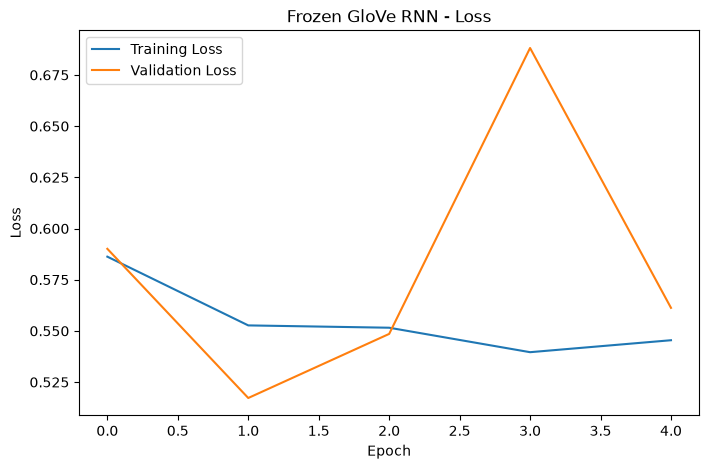

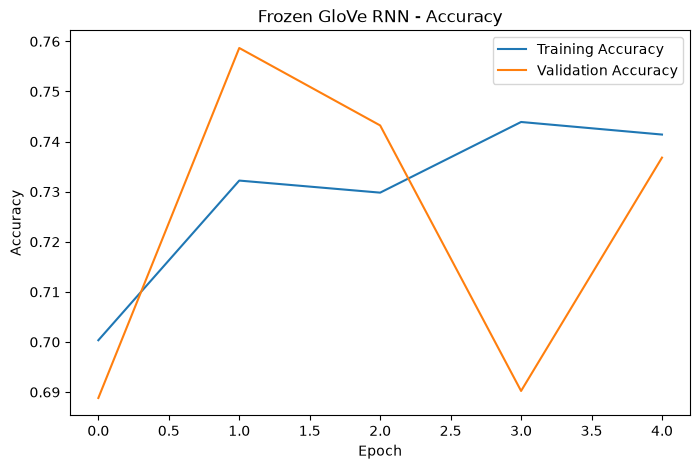

In [24]:
plot_training_history(glove_frozen_history, "Frozen GloVe RNN")

In [25]:
import gc

del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine-tuned GloVe RNN

In [26]:
glove_finetuned_model = RNNClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(glove_finetuned_model.parameters(), lr=LEARNING_RATE)

print("Training Fine-Tuned GloVe RNN...")
print("Device:", device)

glove_finetuned_history = train_model(
    model=glove_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_glove_finetuned.pt"
)

Training Fine-Tuned GloVe RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.5442 | Train Accuracy: 0.7327 | Val Loss: 0.4899 | Val Accuracy: 0.7745
Best model saved.
Epoch 02/5 | Train Loss: 0.4144 | Train Accuracy: 0.8262 | Val Loss: 0.4284 | Val Accuracy: 0.8149
Best model saved.
Epoch 03/5 | Train Loss: 0.3357 | Train Accuracy: 0.8662 | Val Loss: 0.4413 | Val Accuracy: 0.8143
Epoch 04/5 | Train Loss: 0.2621 | Train Accuracy: 0.8983 | Val Loss: 0.4747 | Val Accuracy: 0.8043
Epoch 05/5 | Train Loss: 0.2003 | Train Accuracy: 0.9255 | Val Loss: 0.4735 | Val Accuracy: 0.8069

Training completed in 6.17 minutes.


In [27]:
(
    glove_finetuned_metrics,
    glove_finetuned_labels,
    glove_finetuned_predictions,
    glove_finetuned_probabilities
) = evaluate_model(glove_finetuned_model, test_loader, device)

print(glove_finetuned_metrics)
print(classification_report(
    glove_finetuned_labels, glove_finetuned_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(glove_finetuned_labels, glove_finetuned_predictions))

{'accuracy': 0.8202088625458651, 'precision': 0.8132506476175524, 'recall': 0.8327974276527331, 'f1': 0.8229079788712816}
              precision    recall  f1-score   support

    Negative       0.83      0.81      0.82     12361
    Positive       0.81      0.83      0.82     12440

    accuracy                           0.82     24801
   macro avg       0.82      0.82      0.82     24801
weighted avg       0.82      0.82      0.82     24801

[[ 9982  2379]
 [ 2080 10360]]


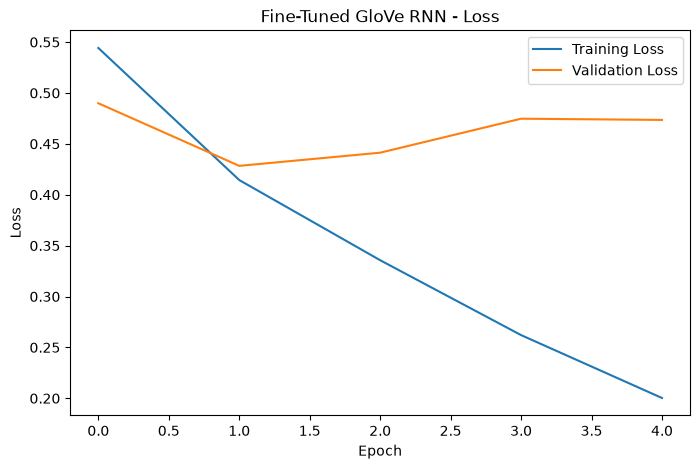

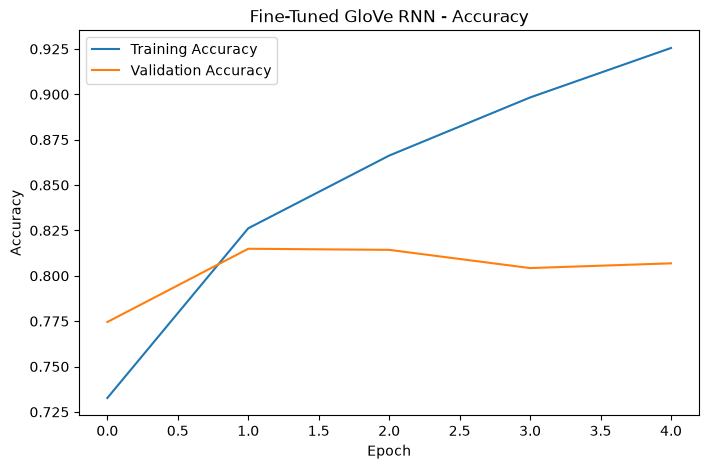

In [28]:
plot_training_history(glove_finetuned_history, "Fine-Tuned GloVe RNN")

In [29]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Frozen Word2Vec RNN

In [30]:
word2vec_frozen_model = RNNClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(lambda parameter: parameter.requires_grad, word2vec_frozen_model.parameters()),
    lr=LEARNING_RATE
)

print("Training Frozen Word2Vec RNN...")
print("Device:", device)

word2vec_frozen_history = train_model(
    model=word2vec_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_word2vec_frozen.pt"
)

Training Frozen Word2Vec RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.4640 | Train Accuracy: 0.7970 | Val Loss: 0.5416 | Val Accuracy: 0.7623
Best model saved.
Epoch 02/5 | Train Loss: 0.4291 | Train Accuracy: 0.8201 | Val Loss: 0.4812 | Val Accuracy: 0.7896
Best model saved.
Epoch 03/5 | Train Loss: 0.4301 | Train Accuracy: 0.8185 | Val Loss: 0.4839 | Val Accuracy: 0.8020
Epoch 04/5 | Train Loss: 0.4339 | Train Accuracy: 0.8191 | Val Loss: 0.4490 | Val Accuracy: 0.8296
Best model saved.
Epoch 05/5 | Train Loss: 0.4129 | Train Accuracy: 0.8285 | Val Loss: 0.3646 | Val Accuracy: 0.8396
Best model saved.

Training completed in 4.27 minutes.


In [31]:
(
    word2vec_frozen_metrics,
    word2vec_frozen_labels,
    word2vec_frozen_predictions,
    word2vec_frozen_probabilities
) = evaluate_model(word2vec_frozen_model, test_loader, device)

print(word2vec_frozen_metrics)
print(classification_report(
    word2vec_frozen_labels, word2vec_frozen_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(word2vec_frozen_labels, word2vec_frozen_predictions))

{'accuracy': 0.8420628200475787, 'precision': 0.8430330837961845, 'recall': 0.8418810289389067, 'f1': 0.8424566625105578}
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84     12361
    Positive       0.84      0.84      0.84     12440

    accuracy                           0.84     24801
   macro avg       0.84      0.84      0.84     24801
weighted avg       0.84      0.84      0.84     24801

[[10411  1950]
 [ 1967 10473]]


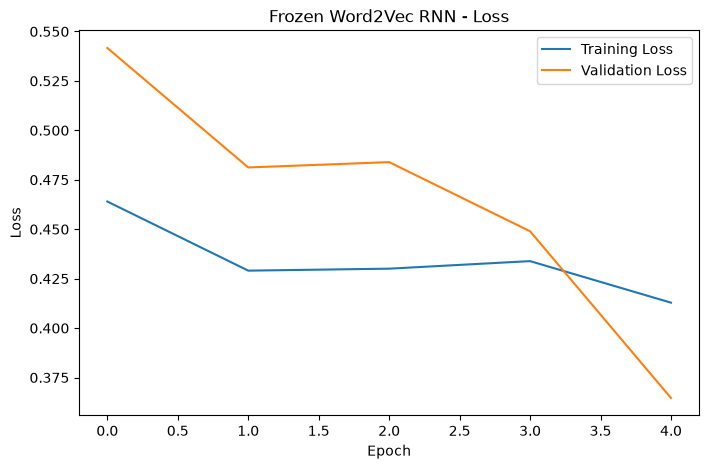

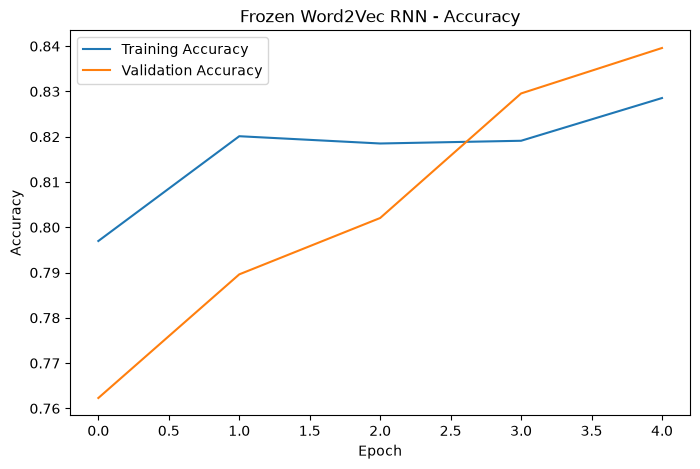

In [32]:
plot_training_history(word2vec_frozen_history, "Frozen Word2Vec RNN")

In [33]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine-tuned Word2Vec RNN

In [34]:
word2vec_finetuned_model = RNNClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(word2vec_finetuned_model.parameters(), lr=LEARNING_RATE)

print("Training Fine-Tuned Word2Vec RNN...")
print("Device:", device)

word2vec_finetuned_history = train_model(
    model=word2vec_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "rnn_word2vec_finetuned.pt"
)

Training Fine-Tuned Word2Vec RNN...
Device: cpu
Epoch 01/5 | Train Loss: 0.4476 | Train Accuracy: 0.8039 | Val Loss: 0.6267 | Val Accuracy: 0.7575
Best model saved.
Epoch 02/5 | Train Loss: 0.3360 | Train Accuracy: 0.8690 | Val Loss: 0.4544 | Val Accuracy: 0.8320
Best model saved.
Epoch 03/5 | Train Loss: 0.2511 | Train Accuracy: 0.9047 | Val Loss: 0.4192 | Val Accuracy: 0.8354
Best model saved.
Epoch 04/5 | Train Loss: 0.2073 | Train Accuracy: 0.9246 | Val Loss: 0.4812 | Val Accuracy: 0.8328
Epoch 05/5 | Train Loss: 0.1364 | Train Accuracy: 0.9531 | Val Loss: 0.6157 | Val Accuracy: 0.7976

Training completed in 5.98 minutes.


In [35]:
(
    word2vec_finetuned_metrics,
    word2vec_finetuned_labels,
    word2vec_finetuned_predictions,
    word2vec_finetuned_probabilities
) = evaluate_model(word2vec_finetuned_model, test_loader, device)

print(word2vec_finetuned_metrics)
print(classification_report(
    word2vec_finetuned_labels, word2vec_finetuned_predictions,
    target_names=["Negative", "Positive"]
))
print(confusion_matrix(word2vec_finetuned_labels, word2vec_finetuned_predictions))

{'accuracy': 0.8336357404943349, 'precision': 0.8231498756218906, 'recall': 0.8512057877813505, 'f1': 0.8369427758457161}
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83     12361
    Positive       0.82      0.85      0.84     12440

    accuracy                           0.83     24801
   macro avg       0.83      0.83      0.83     24801
weighted avg       0.83      0.83      0.83     24801

[[10086  2275]
 [ 1851 10589]]


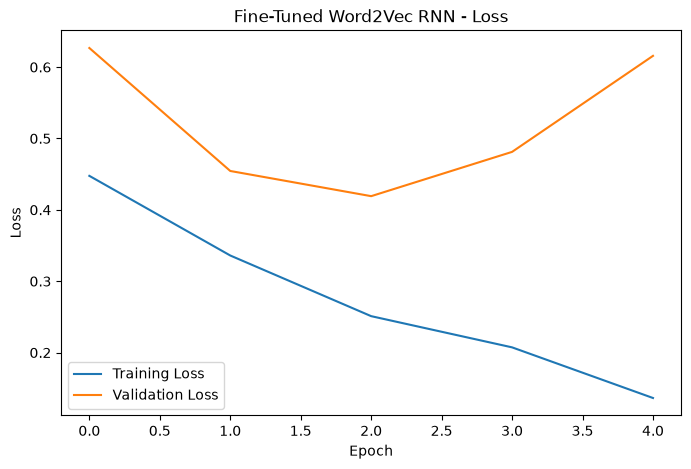

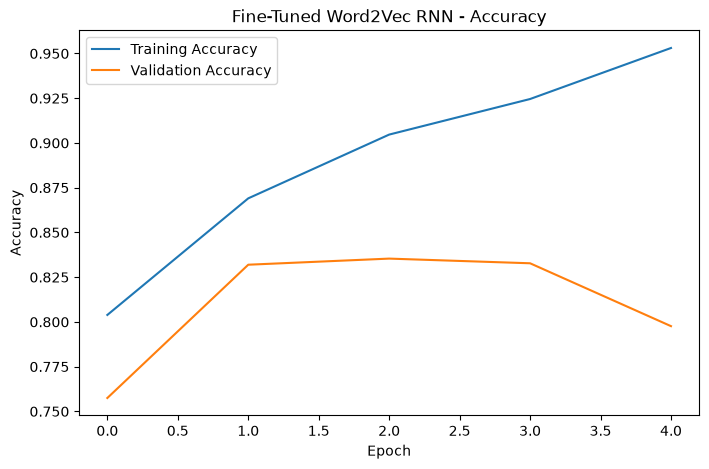

In [36]:
plot_training_history(word2vec_finetuned_history, "Fine-Tuned Word2Vec RNN")

# Results Comparison

In [37]:
results = [
    {"Model": "RNN", "Embedding": "GloVe", "Variant": "Frozen", **glove_frozen_metrics},
    {"Model": "RNN", "Embedding": "GloVe", "Variant": "Fine-Tuned", **glove_finetuned_metrics},
    {"Model": "RNN", "Embedding": "Word2Vec", "Variant": "Frozen", **word2vec_frozen_metrics},
    {"Model": "RNN", "Embedding": "Word2Vec", "Variant": "Fine-Tuned", **word2vec_finetuned_metrics},
]

results_df = pd.DataFrame(results)
results_df

,Model,Embedding,Variant,accuracy,precision,recall,f1
0,RNN,GloVe,Frozen,0.751381,0.760765,0.735691,0.748018
1,RNN,GloVe,Fine-Tuned,0.820209,0.813251,0.832797,0.822908
2,RNN,Word2Vec,Frozen,0.842063,0.843033,0.841881,0.842457
3,RNN,Word2Vec,Fine-Tuned,0.833636,0.823150,0.851206,0.836943


In [38]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(RESULTS_DIR / "rnn_results.csv", index=False)
print("Results saved.")

Results saved.


In [39]:
best_variant_row = results_df.loc[results_df["f1"].idxmax()]
print("Best RNN variant:")
print(best_variant_row)

Best RNN variant:
Model             RNN
Embedding    Word2Vec
Variant        Frozen
accuracy     0.842063
precision    0.843033
recall       0.841881
f1           0.842457
Name: 2, dtype: object


# Error Analysis

Analyzing errors for best variant: Word2Vec (Frozen)
F1: 0.8425
Total test samples: 24801
Misclassified: 3917 (15.79%)
False positives (predicted positive, actually negative): 1950
False negatives (predicted negative, actually positive): 1967

--- Sample False Positives ---
[length=142, confidence=0.947] brass picture movie not fitting word really somewhat brassy alluring visual quality reminiscent expensive high class tv commercial unfortunately brass picture feature film pretense wanting entertain v

[length=115, confidence=0.506] decidedly average italian post apocalyptic take hunting killing human sport theme ala dangerous game turkey shoot gymkata running man certainly film reviewed nowhere near much fun listed entry further

[length=117, confidence=0.946] earth destroyed nuclear holocaust well part earth somewhere italy band purebred survivor without radioactive contamination holed massive mansion surrounded lush ground waiting next opportunity go hunt

[length=48, confidence=0.9

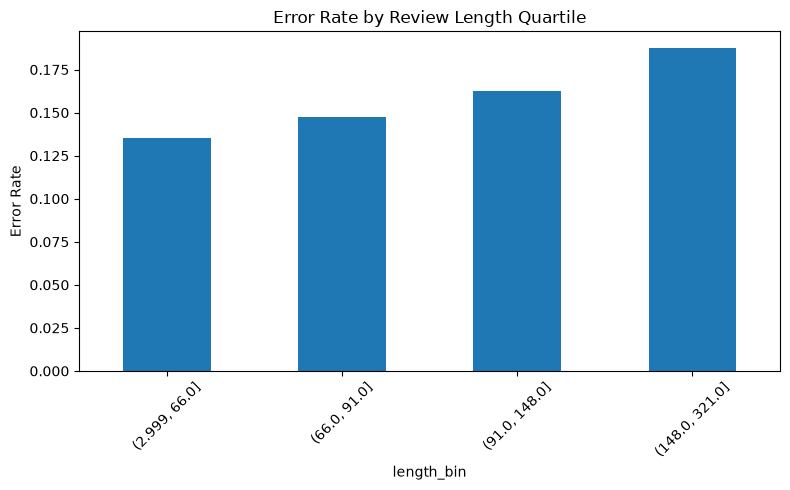

In [40]:
test_df = pd.read_csv(DATA_DIR / "test_processed.csv")

variant_results = {
    ("GloVe", "Frozen"): (glove_frozen_labels, glove_frozen_predictions, glove_frozen_probabilities),
    ("GloVe", "Fine-Tuned"): (glove_finetuned_labels, glove_finetuned_predictions, glove_finetuned_probabilities),
    ("Word2Vec", "Frozen"): (word2vec_frozen_labels, word2vec_frozen_predictions, word2vec_frozen_probabilities),
    ("Word2Vec", "Fine-Tuned"): (word2vec_finetuned_labels, word2vec_finetuned_predictions, word2vec_finetuned_probabilities),
}

best_labels, best_predictions, best_probabilities = variant_results[
    (best_variant_row["Embedding"], best_variant_row["Variant"])
]

print(f"Analyzing errors for best variant: {best_variant_row['Embedding']} ({best_variant_row['Variant']})")
print(f"F1: {best_variant_row['f1']:.4f}")


def analyze_errors(labels, predictions, probabilities, texts, lengths, n_examples=5):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions).reshape(-1)
    probabilities = np.asarray(probabilities).reshape(-1)
    lengths = np.asarray(lengths)
    texts = texts.reset_index(drop=True)

    misclassified_mask = predictions != labels
    false_positive_mask = misclassified_mask & (predictions == 1)
    false_negative_mask = misclassified_mask & (predictions == 0)

    print(f"Total test samples: {len(labels)}")
    print(f"Misclassified: {misclassified_mask.sum()} ({misclassified_mask.mean() * 100:.2f}%)")
    print(f"False positives (predicted positive, actually negative): {false_positive_mask.sum()}")
    print(f"False negatives (predicted negative, actually positive): {false_negative_mask.sum()}")

    print("\n--- Sample False Positives ---")
    for idx in np.where(false_positive_mask)[0][:n_examples]:
        print(f"[length={lengths[idx]}, confidence={probabilities[idx]:.3f}] {texts[idx][:200]}")
        print()

    print("--- Sample False Negatives ---")
    for idx in np.where(false_negative_mask)[0][:n_examples]:
        print(f"[length={lengths[idx]}, confidence={probabilities[idx]:.3f}] {texts[idx][:200]}")
        print()

    length_bins = pd.qcut(lengths, q=4, duplicates="drop")
    error_by_length = pd.DataFrame({
        "length_bin": length_bins,
        "is_error": misclassified_mask
    }).groupby("length_bin", observed=True)["is_error"].mean()

    print("--- Error rate by review length quartile ---")
    print(error_by_length)

    plt.figure(figsize=(8, 5))
    error_by_length.plot(kind="bar")
    plt.ylabel("Error Rate")
    plt.title("Error Rate by Review Length Quartile")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return misclassified_mask, false_positive_mask, false_negative_mask


misclassified_mask, false_positive_mask, false_negative_mask = analyze_errors(
    best_labels, best_predictions, best_probabilities,
    test_df["processed_text"], test_lengths
)

# Save Best Model

In [41]:
checkpoint_filenames = {
    ("GloVe", "Frozen"): "rnn_glove_frozen.pt",
    ("GloVe", "Fine-Tuned"): "rnn_glove_finetuned.pt",
    ("Word2Vec", "Frozen"): "rnn_word2vec_frozen.pt",
    ("Word2Vec", "Fine-Tuned"): "rnn_word2vec_finetuned.pt",
}

best_checkpoint_path = MODELS_DIR / checkpoint_filenames[
    (best_variant_row["Embedding"], best_variant_row["Variant"])
]

print("Best RNN variant:", best_variant_row["Embedding"], best_variant_row["Variant"])
print("Best checkpoint saved at:", best_checkpoint_path)

Best RNN variant: Word2Vec Frozen
Best checkpoint saved at: models\rnn_word2vec_frozen.pt
